
 Train dataset shape: (750000, 31)


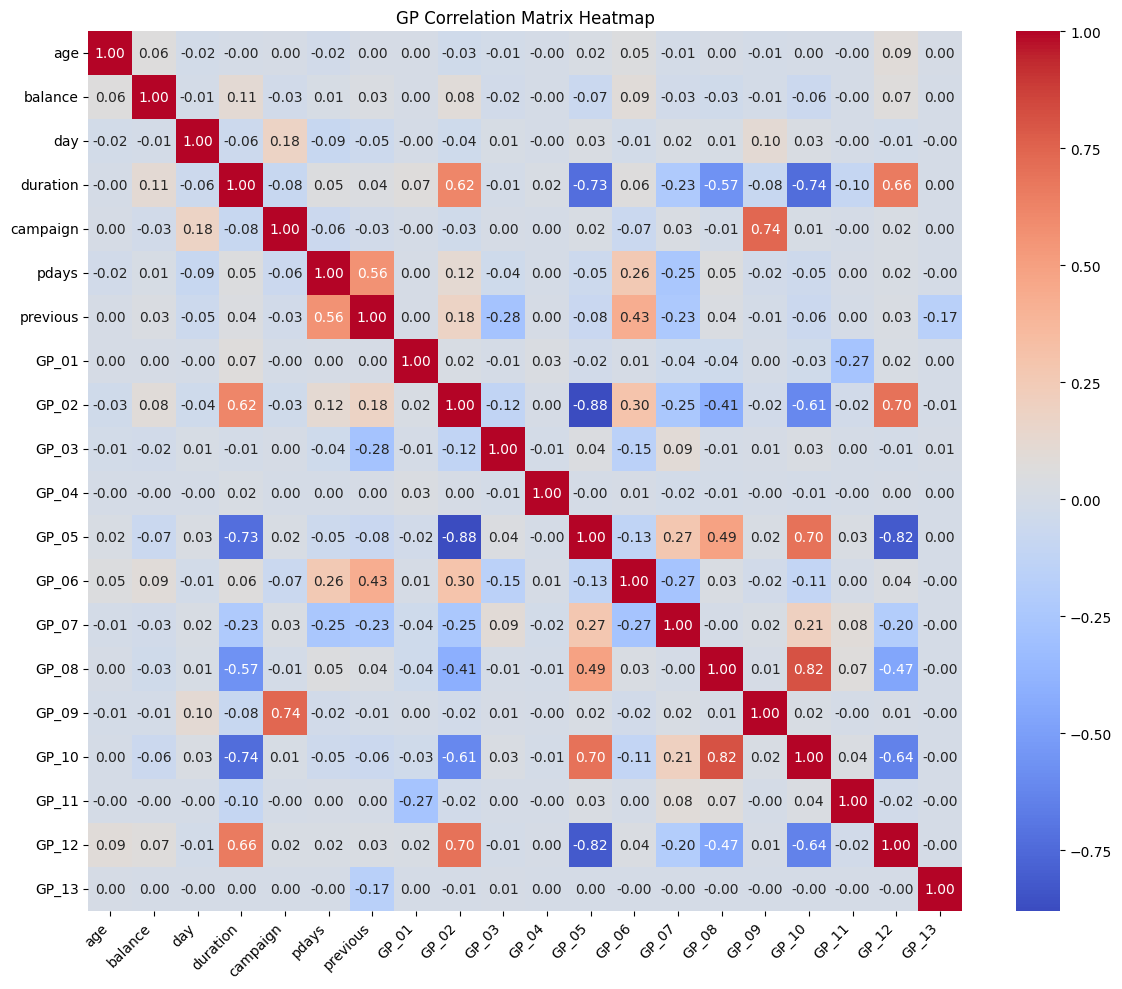

 Test dataset shape: (250000, 30)
 Original dataset shape: (45211, 30)


In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
train_full = pd.read_csv('/kaggle/input/playground-series-s5e8/train.csv')
# Only numberical variables are used for feature generation
cols_scale = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
train = train_full[cols_scale]
train[cols_scale] = scaler.fit_transform(train[cols_scale].values)
train['GP_01'] = np.exp((train['duration'] + np.sin(np.sin(train['pdays'])*np.sqrt(np.abs(np.sin(train['day'])))) - np.where(np.abs(2.423949) < 1.0e-6, 0, np.log(2.423949)))*(train['campaign'] + 0.258862 + np.where(False, -0.982554, 3.283859) - np.where(np.abs(3.439594) < 1.0e-6, 0, np.log(3.439594)))**(-1))
train['GP_02'] = np.exp(np.where(train['duration'] < 1.610414, np.cos(np.exp(np.where(1.508758417128*train['pdays']/np.cos(train['pdays']) - 0.534909 <= train['pdays'], np.sqrt(np.abs(1.824789)), train['age']))), np.sin(0.518444)))
train['GP_03'] = np.exp(np.where(1.508758417128*train['pdays']/np.cos(train['pdays']) - 0.534909 <= train['pdays'], np.sqrt(np.abs(1.824789)), 1/train['previous']))
train['GP_04'] = np.exp(train['duration'] - np.exp(np.where(1.508758417128*train['pdays']/np.cos(train['pdays']) - 0.534909 <= train['pdays'], np.exp(train['duration']), train['age'])))
train['GP_05'] = np.exp(np.where(train['duration'] < 1.610414, np.cos(np.exp(train['duration'] - np.exp(np.where(0.516284*train['pdays']*(train['duration'] + 2.534676)/np.cos(train['pdays']) - 0.534909 <= train['pdays'], np.sqrt(np.abs(np.exp(train['duration']))), train['age'])))), np.sin(0.518444)))
train['GP_06'] = np.exp(0.45584294934035*np.sin(np.sin(train['pdays'])*np.sqrt(np.abs(np.sin(train['day'])))) + 1.10494006121059)
train['GP_07'] = np.exp(np.cos(np.exp(train['duration'] - np.exp(np.exp(np.cos(np.exp(train['pdays'])))))))
train['GP_08'] = np.cos(np.exp(train['duration'] - np.exp(train['pdays']) - np.exp(np.exp(-0.240221))))
train['GP_09'] = np.sqrt(np.abs(train['campaign']*np.cos(np.sqrt(np.abs(np.cos(np.sqrt(np.abs(2.91495)))*np.where(train['pdays'] < train['campaign'], train['day'], -0.687117))))))
train['GP_10'] = np.exp(np.cos(np.exp(train['duration'] - np.exp(np.cos(np.exp(np.cos(train['duration']) - np.exp(np.cos(np.exp(np.sin(train['pdays'] + 0.178461))))))))))
train['GP_11'] = np.cos(np.exp(train['duration'] - np.cos(np.exp(train['duration'] - np.exp(-0.240221) - np.exp(train['pdays']))) - np.exp(np.exp(np.exp(-0.240221)))))
train['GP_12'] = (train['balance'] - train['duration'] + np.exp(np.sqrt(np.abs(np.exp(2.136486*np.where(np.abs(np.where(np.abs(4.411698) < 1.0e-6, 0, np.log(4.411698))) < 1.0e-6, 0, np.log(np.where(np.abs(4.411698) < 1.0e-6, 0, np.log(4.411698))))**(-1))))))*np.sqrt(np.abs(np.where(train['duration'] <= 2.641809 - np.sqrt(np.abs(np.where(train['age'] <= 2.641809, np.where(np.abs(3.880161) < 1.0e-6, 0, np.log(3.880161)), np.exp(3.17722)))), train['duration'] + np.where(np.abs(3.880161) < 1.0e-6, 0, np.log(3.880161)), np.sin(3.17722))))**(-1)
train['GP_13'] = -(np.sqrt(np.abs(np.exp(train['duration'] + np.sqrt(np.abs(4.321697)) - 2.977918))) + np.sqrt(np.abs(np.sqrt(np.abs(np.exp(train['previous']))))))*np.sqrt(np.abs(train['duration'] + 1.405035)) + np.where(np.abs(np.exp(np.cos(train['age']))) < 1.0e-6, 0, np.log(np.exp(np.cos(train['age']))))
GP_cols = train.loc[:, train.columns.str.startswith('GP_')].columns.tolist()
train.drop(cols_scale, axis=1, inplace=True)
scaler2 = StandardScaler()
train[train.columns.tolist()] = scaler2.fit_transform(train[train.columns.tolist()].values)
train_full = pd.concat([train_full, train], axis=1)
train_full.to_csv('train_GP.csv', index=False)
print("\n Train dataset shape:", train_full.shape)

df = train_full.drop(['id'], axis=1)
correlation_matrix = df[cols_scale + GP_cols].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('GP Correlation Matrix Heatmap')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('GP_correlation.png', dpi=150)
plt.show()

test_full = pd.read_csv('/kaggle/input/playground-series-s5e8/test.csv')
test = test_full[cols_scale]
test[cols_scale] = scaler.transform(test[cols_scale].values)
test['GP_01'] = np.exp((test['duration'] + np.sin(np.sin(test['pdays'])*np.sqrt(np.abs(np.sin(test['day'])))) - np.where(np.abs(2.423949) < 1.0e-6, 0, np.log(2.423949)))*(test['campaign'] + 0.258862 + np.where(False, -0.982554, 3.283859) - np.where(np.abs(3.439594) < 1.0e-6, 0, np.log(3.439594)))**(-1))
test['GP_02'] = np.exp(np.where(test['duration'] < 1.610414, np.cos(np.exp(np.where(1.508758417128*test['pdays']/np.cos(test['pdays']) - 0.534909 <= test['pdays'], np.sqrt(np.abs(1.824789)), test['age']))), np.sin(0.518444)))
test['GP_03'] = np.exp(np.where(1.508758417128*test['pdays']/np.cos(test['pdays']) - 0.534909 <= test['pdays'], np.sqrt(np.abs(1.824789)), 1/test['previous']))
test['GP_04'] = np.exp(test['duration'] - np.exp(np.where(1.508758417128*test['pdays']/np.cos(test['pdays']) - 0.534909 <= test['pdays'], np.exp(test['duration']), test['age'])))
test['GP_05'] = np.exp(np.where(test['duration'] < 1.610414, np.cos(np.exp(test['duration'] - np.exp(np.where(0.516284*test['pdays']*(test['duration'] + 2.534676)/np.cos(test['pdays']) - 0.534909 <= test['pdays'], np.sqrt(np.abs(np.exp(test['duration']))), test['age'])))), np.sin(0.518444)))
test['GP_06'] = np.exp(0.45584294934035*np.sin(np.sin(test['pdays'])*np.sqrt(np.abs(np.sin(test['day'])))) + 1.10494006121059)
test['GP_07'] = np.exp(np.cos(np.exp(test['duration'] - np.exp(np.exp(np.cos(np.exp(test['pdays'])))))))
test['GP_08'] = np.cos(np.exp(test['duration'] - np.exp(test['pdays']) - np.exp(np.exp(-0.240221))))
test['GP_09'] = np.sqrt(np.abs(test['campaign']*np.cos(np.sqrt(np.abs(np.cos(np.sqrt(np.abs(2.91495)))*np.where(test['pdays'] < test['campaign'], test['day'], -0.687117))))))
test['GP_10'] = np.exp(np.cos(np.exp(test['duration'] - np.exp(np.cos(np.exp(np.cos(test['duration']) - np.exp(np.cos(np.exp(np.sin(test['pdays'] + 0.178461))))))))))
test['GP_11'] = np.cos(np.exp(test['duration'] - np.cos(np.exp(test['duration'] - np.exp(-0.240221) - np.exp(test['pdays']))) - np.exp(np.exp(np.exp(-0.240221)))))
test['GP_12'] = (test['balance'] - test['duration'] + np.exp(np.sqrt(np.abs(np.exp(2.136486*np.where(np.abs(np.where(np.abs(4.411698) < 1.0e-6, 0, np.log(4.411698))) < 1.0e-6, 0, np.log(np.where(np.abs(4.411698) < 1.0e-6, 0, np.log(4.411698))))**(-1))))))*np.sqrt(np.abs(np.where(test['duration'] <= 2.641809 - np.sqrt(np.abs(np.where(test['age'] <= 2.641809, np.where(np.abs(3.880161) < 1.0e-6, 0, np.log(3.880161)), np.exp(3.17722)))), test['duration'] + np.where(np.abs(3.880161) < 1.0e-6, 0, np.log(3.880161)), np.sin(3.17722))))**(-1)
test['GP_13'] = -(np.sqrt(np.abs(np.exp(test['duration'] + np.sqrt(np.abs(4.321697)) - 2.977918))) + np.sqrt(np.abs(np.sqrt(np.abs(np.exp(test['previous']))))))*np.sqrt(np.abs(test['duration'] + 1.405035)) + np.where(np.abs(np.exp(np.cos(test['age']))) < 1.0e-6, 0, np.log(np.exp(np.cos(test['age']))))
test.drop(cols_scale, axis=1, inplace=True)
test[test.columns.tolist()] = scaler2.transform(test[test.columns.tolist()].values)
test_full = pd.concat([test_full, test], axis=1)
test_full.to_csv('test_GP.csv', index=False)
print(" Test dataset shape:", test_full.shape)

original_full = pd.read_csv('/kaggle/input/bank-marketing-dataset-full/bank-full.csv', sep=";")
original_full['y'] = (original_full['y']=='yes').astype(int)
original = original_full[cols_scale]
original[cols_scale] = scaler.transform(original[cols_scale].values)
original['GP_01'] = np.exp((original['duration'] + np.sin(np.sin(original['pdays'])*np.sqrt(np.abs(np.sin(original['day'])))) - np.where(np.abs(2.423949) < 1.0e-6, 0, np.log(2.423949)))*(original['campaign'] + 0.258862 + np.where(False, -0.982554, 3.283859) - np.where(np.abs(3.439594) < 1.0e-6, 0, np.log(3.439594)))**(-1))
original['GP_02'] = np.exp(np.where(original['duration'] < 1.610414, np.cos(np.exp(np.where(1.508758417128*original['pdays']/np.cos(original['pdays']) - 0.534909 <= original['pdays'], np.sqrt(np.abs(1.824789)), original['age']))), np.sin(0.518444)))
original['GP_03'] = np.exp(np.where(1.508758417128*original['pdays']/np.cos(original['pdays']) - 0.534909 <= original['pdays'], np.sqrt(np.abs(1.824789)), 1/original['previous']))
original['GP_04'] = np.exp(original['duration'] - np.exp(np.where(1.508758417128*original['pdays']/np.cos(original['pdays']) - 0.534909 <= original['pdays'], np.exp(original['duration']), original['age'])))
original['GP_05'] = np.exp(np.where(original['duration'] < 1.610414, np.cos(np.exp(original['duration'] - np.exp(np.where(0.516284*original['pdays']*(original['duration'] + 2.534676)/np.cos(original['pdays']) - 0.534909 <= original['pdays'], np.sqrt(np.abs(np.exp(original['duration']))), original['age'])))), np.sin(0.518444)))
original['GP_06'] = np.exp(0.45584294934035*np.sin(np.sin(original['pdays'])*np.sqrt(np.abs(np.sin(original['day'])))) + 1.10494006121059)
original['GP_07'] = np.exp(np.cos(np.exp(original['duration'] - np.exp(np.exp(np.cos(np.exp(original['pdays'])))))))
original['GP_08'] = np.cos(np.exp(original['duration'] - np.exp(original['pdays']) - np.exp(np.exp(-0.240221))))
original['GP_09'] = np.sqrt(np.abs(original['campaign']*np.cos(np.sqrt(np.abs(np.cos(np.sqrt(np.abs(2.91495)))*np.where(original['pdays'] < original['campaign'], original['day'], -0.687117))))))
original['GP_10'] = np.exp(np.cos(np.exp(original['duration'] - np.exp(np.cos(np.exp(np.cos(original['duration']) - np.exp(np.cos(np.exp(np.sin(original['pdays'] + 0.178461))))))))))
original['GP_11'] = np.cos(np.exp(original['duration'] - np.cos(np.exp(original['duration'] - np.exp(-0.240221) - np.exp(original['pdays']))) - np.exp(np.exp(np.exp(-0.240221)))))
original['GP_12'] = (original['balance'] - original['duration'] + np.exp(np.sqrt(np.abs(np.exp(2.136486*np.where(np.abs(np.where(np.abs(4.411698) < 1.0e-6, 0, np.log(4.411698))) < 1.0e-6, 0, np.log(np.where(np.abs(4.411698) < 1.0e-6, 0, np.log(4.411698))))**(-1))))))*np.sqrt(np.abs(np.where(original['duration'] <= 2.641809 - np.sqrt(np.abs(np.where(original['age'] <= 2.641809, np.where(np.abs(3.880161) < 1.0e-6, 0, np.log(3.880161)), np.exp(3.17722)))), original['duration'] + np.where(np.abs(3.880161) < 1.0e-6, 0, np.log(3.880161)), np.sin(3.17722))))**(-1)
original['GP_13'] = -(np.sqrt(np.abs(np.exp(original['duration'] + np.sqrt(np.abs(4.321697)) - 2.977918))) + np.sqrt(np.abs(np.sqrt(np.abs(np.exp(original['previous']))))))*np.sqrt(np.abs(original['duration'] + 1.405035)) + np.where(np.abs(np.exp(np.cos(original['age']))) < 1.0e-6, 0, np.log(np.exp(np.cos(original['age']))))
original.drop(cols_scale, axis=1, inplace=True)
original[original.columns.tolist()] = scaler2.transform(original[original.columns.tolist()].values)
original_full = pd.concat([original_full, original], axis=1)
original_full.to_csv('original_GP.csv', index=False)
print(" Original dataset shape:", original_full.shape)
